<h1><center><b>💻 Assignment 9:</b> </br> Graph Kernel</center></h1>

> 🌸 **Submission Reminder**
>
> Please make sure to **submit your `.ipynb` (Jupyter Notebook) file** for grading.  
> Other formats such as **PDF, screenshots, `.py` files will be accepted</span>**.  
>
> ⚠️ **Important**
>
> **Submission with execution errors is acceptable (e.g., code runs but has errors)**.
>
> **However, a <span style="color:red;">.ipynb file with no executed cells (e.g., nothing has been run)</span> will be scored as 0**.
>
> Thank you and happy coding! 💻✨

# 1. Weisfeiler Lehman:
### 1.1. Initialize graphs as the following image:
![image info](./data/graph_3.png)

G3.add_edges_from(
    [
        (1, 2, {"label": "Friendship"}),
        (1, 3, {"label": "Friendship"}),
        (1, 4, {"label": "Friendship"}),
        (3, 4, {"label": "Friendship"}),
    ]
)
G3_node_attributes = {
    1: "Sophia",
    2: "Liam",
    3: "Olivia",
    4: "Ethan",
}

G4.add_edges_from(
    [
        (5, 6, {"label": "Friendship"}),
        (5, 7, {"label": "Friendship"}),
        (5, 8, {"label": "Friendship"}),
        (6, 8, {"label": "Friendship"}),
    ]
)
G4_node_attributes = {
    5: "Isabella",
    6: "Noah",
    7: "Ava",
    8: "Lucas",
}

### 1.2. Compute WL to compare 2 above graphs WITHOUT labels
### 1.3. Compute WL to compare 2 above graphs WITH NODE labels
### 1.4. Compute WL to compare 2 above graphs WITH EDGE labels
### 1.5. Compute 3-WL to compare 2 above graphs WITHOUT labels

In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import hashlib
from collections import Counter
import copy
import itertools
from hashlib import blake2b

In [3]:
G3 = nx.Graph()
G3.add_edges_from(
    [
        (1, 2, {"label": "Friendship"}),
        (1, 3, {"label": "Friendship"}),
        (1, 4, {"label": "Friendship"}),
        (3, 4, {"label": "Friendship"}),
    ]
)
G3_node_attributes = {
    1: "Sophia",
    2: "Liam",
    3: "Olivia",
    4: "Ethan",
}
nx.set_node_attributes(G3, G3_node_attributes, name="label")

G4 = nx.Graph()
G4.add_edges_from(
    [
        (5, 6, {"label": "Friendship"}),
        (5, 7, {"label": "Friendship"}),
        (5, 8, {"label": "Friendship"}),
        (6, 8, {"label": "Friendship"}),
    ]
)
G4_node_attributes = {
    5: "Isabella",
    6: "Noah",
    7: "Ava",
    8: "Lucas",
}
nx.set_node_attributes(G4, G4_node_attributes, name="label")

print("G3 edges:", list(G3.edges()))
print("G3 nodes labels:", nx.get_node_attributes(G3, 'label'))
print("G4 edges:", list(G4.edges()))
print("G4 nodes labels:", nx.get_node_attributes(G4, 'label'))

G3 edges: [(1, 2), (1, 3), (1, 4), (3, 4)]
G3 nodes labels: {1: 'Sophia', 2: 'Liam', 3: 'Olivia', 4: 'Ethan'}
G4 edges: [(5, 6), (5, 7), (5, 8), (6, 8)]
G4 nodes labels: {5: 'Isabella', 6: 'Noah', 7: 'Ava', 8: 'Lucas'}


In [4]:
# 1.2. Compute WL to compare 2 above graphs WITHOUT labels

def _hash_label(label, digest_size):
    return blake2b(label.encode("ascii"), digest_size=digest_size).hexdigest()

def _init_node_labels(G, edge_attr, node_attr):
    if node_attr:
        return {u: str(dd[node_attr]) for u, dd in G.nodes(data=True)}
    elif edge_attr:
        return {u: "" for u in G}
    else:
        return {u: str(deg) for u, deg in G.degree()}

def _neighborhood_aggregate(G, node, node_labels, edge_attr=None):
    label_list = []
    for nbr in G.neighbors(node):
        prefix = "" if edge_attr is None else str(G[node][nbr][edge_attr])
        label_list.append(prefix + node_labels[nbr])
    return node_labels[node] + "".join(sorted(label_list))

def weisfeiler_lehman_graph_hash(
    G, edge_attr=None, node_attr=None, iterations=3, digest_size=16
):
    def weisfeiler_lehman_step(G, labels, edge_attr=None):
        new_labels = {}
        for node in G.nodes():
            label = _neighborhood_aggregate(G, node, labels, edge_attr=edge_attr)
            new_labels[node] = _hash_label(label, digest_size)
        return new_labels

    node_labels = _init_node_labels(G, edge_attr, node_attr)
    subgraph_hash_counts = []
    for _ in range(iterations):
        node_labels = weisfeiler_lehman_step(G, node_labels, edge_attr=edge_attr)
        counter = Counter(node_labels.values())
        subgraph_hash_counts.extend(sorted(counter.items(), key=lambda x: x[0]))
    return _hash_label(str(tuple(subgraph_hash_counts)), digest_size)

g3_hash = weisfeiler_lehman_graph_hash(G3)
g4_hash = weisfeiler_lehman_graph_hash(G4)
print("Without labels:")
print(f"G3 hash: {g3_hash}")
print(f"G4 hash: {g4_hash}")
print(f"Hashes equal (isomorphic): {g3_hash==g4_hash}")

Without labels:
G3 hash: 7bc4dde9a09d0b94c5097b219891d81a
G4 hash: 7bc4dde9a09d0b94c5097b219891d81a
Hashes equal (isomorphic): True


In [5]:
# 1.3. Compute WL to compare 2 above graphs WITH NODE labels

g3_hash_node = weisfeiler_lehman_graph_hash(G3, node_attr="label")
g4_hash_node = weisfeiler_lehman_graph_hash(G4, node_attr="label")
print("With node labels:")
print(f"G3 hash: {g3_hash_node}")
print(f"G4 hash: {g4_hash_node}")
print(f"Hashes equal: {g3_hash_node==g4_hash_node}")

With node labels:
G3 hash: d5b7708a65f698837cfe707e2821a280
G4 hash: f81ec10dbf26184f11d479e3f271a417
Hashes equal: False


In [6]:
# 1.4. Compute WL to compare 2 above graphs WITH EDGE labels

g3_hash_edge = weisfeiler_lehman_graph_hash(G3, edge_attr="label")
g4_hash_edge = weisfeiler_lehman_graph_hash(G4, edge_attr="label")
print("With edge labels:")
print(f"G3 hash: {g3_hash_edge}")
print(f"G4 hash: {g4_hash_edge}")
print(f"Hashes equal: {g3_hash_edge==g4_hash_edge}")

With edge labels:
G3 hash: 92efe26c38838089f23c1bb529264194
G4 hash: 92efe26c38838089f23c1bb529264194
Hashes equal: True


In [7]:
# 1.5. Compute 3-WL to compare 2 above graphs WITHOUT labels

# WL and kWL implementations from Practice 9
def compute_base_WL(graph, k, verbose, n_set, initial_colors_func, find_neighbors_func):    
    G, n = n_set(graph)
    colors = initial_colors_func(n)
    old_colors = copy.deepcopy(colors)
    for i in range(len(n)):
        for node in n:
            neigh_colors = "".join([colors[i][0] for i in find_neighbors_func(G, n, node)])
            colors[node].extend([neigh_colors])
            colors[node].sort()
        colors = {i: [hashlib.sha224("".join(colors[i]).encode('utf-8')).hexdigest()] for i in colors}
        if list(Counter([item for sublist in colors.values() for item in sublist]).values()) == list(Counter([item for sublist in old_colors.values() for item in sublist]).values()) and i != 0:
            if verbose:
                print(f'Converged at iteration {i}!')
            break
        old_colors = copy.deepcopy(colors)
    canonical_form = sorted(Counter([item for sublist in colors.values() for item in sublist]).items())
    if verbose:
        print(f'Canonical Form Found: \n {canonical_form} \n')
    return canonical_form

def kWL(G, k, verbose=False):
    def n_set(G):
        G = nx.convert_node_labels_to_integers(G)
        V = list(G.nodes())
        V_k = [comb for comb in itertools.combinations(V, k)]
        return G, V_k
    def set_initial_colors(n):
        return {i: [hashlib.sha224(str(i).encode('utf-8')).hexdigest()] for i in n}
    def find_neighbors(G, V_k, node):
        return [n for n in V_k if len(set(n) - set(V_k[V_k.index(node)])) == 1]
    return compute_base_WL(G, k, verbose, n_set, set_initial_colors, find_neighbors)

print("Using kWL (k=3) for 3-WL:")
cf3 = kWL(G3, 3, verbose=False)
cf4 = kWL(G4, 3, verbose=False)
print(f"G3 canonical form length: {len(cf3)}")
print(f"G4 canonical form length: {len(cf4)}")
print(f"3-WL equal (isomorphic): {cf3 == cf4}")

Using kWL (k=3) for 3-WL:
G3 canonical form length: 4
G4 canonical form length: 4
3-WL equal (isomorphic): True


# 2. Other methods:
### 2.1. Create graphs as the following image:
![image info](./data/graph_4.png)

### 2.2. Using Shortest Path Kernel to compare 2 above graphs

### 2.3. Using Pyramid Match Graph Kernel to compare 2 above graphs

### 2.4. Using Random Walk Kernel to compare 2 above graphs

### 2.5. Using Graphlet Kernel to compare 2 above graphs

G5 edges: [(1, 2), (1, 4), (1, 3), (2, 3), (3, 4)]
G6 edges: [(5, 6), (5, 8), (6, 7), (7, 8)]


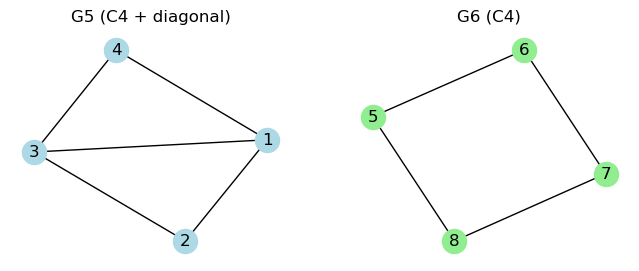

In [8]:
G5 = nx.Graph()
G5.add_edges_from([(1,2),(2,3),(3,4),(4,1),(1,3)])
G5_node_attributes = {1:'A',2:'B',3:'C',4:'D'}
nx.set_node_attributes(G5, G5_node_attributes, 'label')

# G6: simple C4 (no triangle)
G6 = nx.Graph()
G6.add_edges_from([(5,6),(6,7),(7,8),(8,5)])
G6_node_attributes = {5:'W',6:'X',7:'Y',8:'Z'}
nx.set_node_attributes(G6, G6_node_attributes, 'label')

print("G5 edges:", list(G5.edges()))
print("G6 edges:", list(G6.edges()))

# Draw for visualization
fig, ax = plt.subplots(1,2, figsize=(8,3))
nx.draw(G5, ax=ax[0], with_labels=True, node_color='lightblue')
ax[0].set_title('G5 (C4 + diagonal)')
nx.draw(G6, ax=ax[1], with_labels=True, node_color='lightgreen')
ax[1].set_title('G6 (C4)')
plt.show()

In [9]:
# 2.2. Using Shortest Path Kernel to compare 2 above graphs

paths_G5 = dict(nx.all_pairs_shortest_path_length(G5))
paths_G6 = dict(nx.all_pairs_shortest_path_length(G6))

K_sp = np.zeros((2, 2))
for i, paths1 in enumerate([paths_G5, paths_G6]):
    for j, paths2 in enumerate([paths_G5, paths_G6]):
        # Simpler: count matching (u,v,d) shortest path lengths
        common = 0
        nodes_i = list(paths1.keys())
        nodes_j = list(paths2.keys())
        for u in nodes_i:
            for v in nodes_i:
                if u > v: continue
                d1 = paths1[u].get(v, -1)
                for a in nodes_j:
                    for b in nodes_j:
                        if a > b: continue
                        d2 = paths2[a].get(b, -1)
                        if d1 == d2 and d1 >= 0:
                            common += 1
        K_sp[i, j] = common
print("Shortest path kernel (manual count based) K:")
print(K_sp)

Shortest path kernel (manual count based) K:
[[42. 38.]
 [38. 36.]]


In [10]:
# 2.3. Using Pyramid Match Graph Kernel to compare 2 above graphs

def pyramid_match_kernel(G1, G2, levels):
    node_attrs_G1 = nx.get_node_attributes(G1, 'label')
    node_attrs_G2 = nx.get_node_attributes(G2, 'label')
    edge_attrs_G1 = nx.get_edge_attributes(G1, 'weight')
    edge_attrs_G2 = nx.get_edge_attributes(G2, 'weight')
    kernel_matrix = np.zeros((levels, levels))
    for level in range(levels):
        features_G1 = extract_features(G1, node_attrs_G1, edge_attrs_G1, level)
        features_G2 = extract_features(G2, node_attrs_G2, edge_attrs_G2, level)
        similarity = compute_similarity(features_G1, features_G2)
        kernel_matrix[level, level] = similarity
    kernel_value = np.sum(kernel_matrix)
    return kernel_value

def extract_features(G, node_attrs, edge_attrs, level):
    # Simplified: use one-hot like from labels + edge count
    labels = sorted(set(node_attrs.values()))
    node_vec = [1 if node_attrs.get(n, '') == l else 0 for n in G.nodes() for l in labels]
    edge_features = [1.0] * len(G.edges())
    features = np.array(node_vec + edge_features, dtype=float)
    return features

def compute_similarity(f1, f2):
    if len(f1) == 0 or len(f2) == 0:
        return 0.0
    # pad
    if len(f1) < len(f2):
        f1 = np.pad(f1, (0, len(f2)-len(f1)))
    elif len(f2) < len(f1):
        f2 = np.pad(f2, (0, len(f1)-len(f2)))
    return np.dot(f1, f2) / (np.linalg.norm(f1) * np.linalg.norm(f2) + 1e-9)

kernel_pm = pyramid_match_kernel(G5, G6, levels=3)
print("Pyramid Match graph kernel value:", kernel_pm)

Pyramid Match graph kernel value: 2.8284271244128565


In [15]:
# 2.4. Using Random Walk Kernel to compare 2 above graphs
import random

def random_walk_kernel(graph1, graph2, walk_length=2, num_walks=20):
    kernel = 0
    for _ in range(num_walks):
        walk1 = random_walk(graph1, walk_length)
        walk2 = random_walk(graph2, walk_length)
        if walk1 == walk2:
            kernel += 1
    kernel /= num_walks
    return kernel

def random_walk(graph, walk_length):
    node = random.choice(list(graph.nodes()))
    walk = [node]
    for _ in range(walk_length - 1):
        neighbors = list(graph.neighbors(node))
        if neighbors:
            node = random.choice(neighbors)
            walk.append(node)
        else:
            break
    return tuple(walk)

kernel_rw = random_walk_kernel(G5, G6, walk_length=2, num_walks=20)
print("Random Walk Kernel Value:", kernel_rw)

Random Walk Kernel Value: 0.0


In [16]:
# 2.5. Using Graphlet Kernel to compare 2 above graphs

from itertools import combinations

def compute_graphlet_counts(G, k):
    graphlet_counts = {graphlet: 0 for graphlet in range(1, k+1)}
    for node in G.nodes():
        subgraph_nodes = [node] + list(G.neighbors(node))
        for graphlet_size in range(1, k+1):
            for subset in combinations(subgraph_nodes, graphlet_size):
                if G.subgraph(subset).number_of_nodes() == graphlet_size:
                    graphlet_counts[graphlet_size] += 1
    return graphlet_counts

def compute_graphlet_kernel(G1, G2, k):
    counts1 = compute_graphlet_counts(G1, k)
    counts2 = compute_graphlet_counts(G2, k)
    kernel_value = sum(min(counts1[s], counts2[s]) for s in range(1, k+1))
    return kernel_value

kernel_gl = compute_graphlet_kernel(G5, G6, k=3)
print("Graphlet kernel value:", kernel_gl)

Graphlet kernel value: 28
